In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import glob
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

DATA_DIR = "/content/drive/MyDrive/data"
SELECTED_ACTIVITIES = ["sit", "walk", "run", "stairs"]
TRAIN_POSITIONS = ["dom_hand"]
TEST_POSITIONS = ["nondom_hand"]
SAMPLING_RATE = 100
TRIM_SECONDS = 2
WINDOW_SIZE = SAMPLING_RATE
STEP_SIZE = SAMPLING_RATE // 2
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3
DROPOUT = 0.3
RANDOM_STATE = 42
EPSILON = 1e-7
GFT_FEATURES = ["ax_g", "ay_g", "az_g", "gx_g", "gy_g", "gz_g"]

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
def load_selected_csvs(base_dir):
    dfs = []
    all_positions = list(set(TRAIN_POSITIONS + TEST_POSITIONS))
    for activity in SELECTED_ACTIVITIES:
        for position in all_positions:
            path = os.path.join(base_dir, activity, position, "*.csv")
            for csv_path in glob.glob(path):
                try:
                    df = pd.read_csv(csv_path)
                    df["activity"] = activity
                    df["phone_position"] = position
                    df["recording_id"] = os.path.splitext(os.path.basename(csv_path))[0]
                    dfs.append(df)
                except Exception as e:
                    print(f"Error loading {csv_path}: {e}")
    print(f"Loaded {len(dfs)} recordings.")
    return dfs

def trim_df(df):
    trim = SAMPLING_RATE * TRIM_SECONDS
    if len(df) <= 2 * trim:
        return None
    return df.iloc[trim:-trim].reset_index(drop=True)

def sliding_windows(df):
    for start in range(0, len(df) - WINDOW_SIZE + 1, STEP_SIZE):
        yield df.iloc[start:start + WINDOW_SIZE]

def build_dataset(dfs, feature_cols):
    X, y, groups = [], [], []
    for df in dfs:
        df = trim_df(df)
        if df is None:
            continue
        for w in sliding_windows(df):
            X.append(w[feature_cols].values)
            y.append(w["activity"].iloc[0])
            groups.append(w["recording_id"].iloc[0])
    return np.array(X), np.array(y), np.array(groups)

In [ ]:
class SinusoidalPositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, d_model):
        super().__init__()
        position = np.arange(WINDOW_SIZE)[:, None]
        div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = np.zeros((WINDOW_SIZE, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.pe = tf.constant(pe[None, ...], dtype=tf.float32)
    def call(self, x):
        return x + self.pe

def inverted_residual_block(x, expand_ratio=4):
    in_channels = x.shape[-1]
    hidden_dim = in_channels * expand_ratio
    y = tf.keras.layers.Conv1D(hidden_dim, 1, use_bias=False)(x)
    y = tf.keras.layers.BatchNormalization()(y)
    y = tf.keras.layers.ReLU()(y)
    y = tf.keras.layers.DepthwiseConv1D(3, padding="same", use_bias=False)(y)
    y = tf.keras.layers.BatchNormalization()(y)
    y = tf.keras.layers.ReLU()(y)
    y = tf.keras.layers.Conv1D(in_channels, 1, use_bias=False)(y)
    y = tf.keras.layers.BatchNormalization()(y)
    return tf.keras.layers.Add()([x, y])

class TransformerEncoderBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim//num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout)
        self.dropout2 = tf.keras.layers.Dropout(dropout)
    def call(self, x, training=False):
        attn = self.mha(x, x, training=training)
        x = self.norm1(x + self.dropout1(attn, training=training))
        ffn_out = self.ffn(x)
        return self.norm2(x + self.dropout2(ffn_out, training=training))

def build_mobilehart(num_classes):
    inputs = tf.keras.Input(shape=(WINDOW_SIZE, 6))
    acc = inputs[:, :, :3]
    gyro = inputs[:, :, 3:]
    acc = inverted_residual_block(acc)
    gyro = inverted_residual_block(gyro)
    x = tf.keras.layers.Concatenate()([acc, gyro])
    x = tf.keras.layers.Conv1D(64, 1)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = SinusoidalPositionalEmbedding(64)(x)
    x = TransformerEncoderBlock(64, 2, 128, DROPOUT)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(DROPOUT)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

In [ ]:
def run_experiment(all_dfs):
    train_dfs = [d for d in all_dfs if d["phone_position"].iloc[0] in TRAIN_POSITIONS]
    test_dfs = [d for d in all_dfs if d["phone_position"].iloc[0] in TEST_POSITIONS]

    X_full, y_full, groups = build_dataset(train_dfs, GFT_FEATURES)
    X_test, y_test, _ = build_dataset(test_dfs, GFT_FEATURES)

    le = LabelEncoder()
    y_full_enc = le.fit_transform(y_full)
    y_test_enc = le.transform(y_test)

    y_full_cat = to_categorical(y_full_enc, num_classes=len(le.classes_))
    y_test_cat = to_categorical(y_test_enc, num_classes=len(le.classes_))

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    train_idx, val_idx = next(splitter.split(X_full, y_full_enc, groups))
    X_train, y_train = X_full[train_idx], y_full_cat[train_idx]
    X_val, y_val = X_full[val_idx], y_full_cat[val_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train.reshape(-1, 6)).reshape(-1, WINDOW_SIZE, 6)
    X_val = scaler.transform(X_val.reshape(-1, 6)).reshape(-1, WINDOW_SIZE, 6)
    X_test = scaler.transform(X_test.reshape(-1, 6)).reshape(-1, WINDOW_SIZE, 6)

    model = build_mobilehart(len(le.classes_))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE
    )

    preds = np.argmax(model.predict(X_test), axis=1)
    print(classification_report(y_test_enc, preds, target_names=le.classes_))

    cm = confusion_matrix(y_test_enc, preds)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cmap="Oranges")
    plt.title("Confusion Matrix")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

    MODEL_DIR = "mobilehart_savedmodel"
    model.export(MODEL_DIR)

    json.dump({
        "mean": scaler.mean_.tolist(),
        "std": (scaler.scale_ + 1e-7).tolist(),
        "labels": le.classes_.tolist()
    }, open("model_metadata.json", "w"))

    !tensorflowjs_converter --input_format=tf_saved_model mobilehart_savedmodel tfjs_model

    !zip -r tfjs_model.zip tfjs_model model_metadata.json

    from google.colab import files
    files.download("tfjs_model.zip")


Loaded 40 recordings.
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 26s 459ms/step - accuracy: 0.4536 - loss: 1.3148 - val_accuracy: 0.3960 - val_loss: 1.1253
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8423 - loss: 0.7040 - val_accuracy: 0.4554 - val_loss: 0.8722
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9024 - loss: 0.5847 - val_accuracy: 0.4455 - val_loss: 0.9713
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9299 - loss: 0.5379 - val_accuracy: 0.4257 - val_loss: 1.1801
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9516 - loss: 0.4900 - val_accuracy: 0.4307 - val_loss: 1.2643
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9565 - loss: 0.4699 - val_accuracy: 0.4257 - val_loss: 1.3750
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9699 - loss: 0.4583 - val_accuracy: 0.4356 - val_loss: 1.2421
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9736 - loss: 0.4421 -

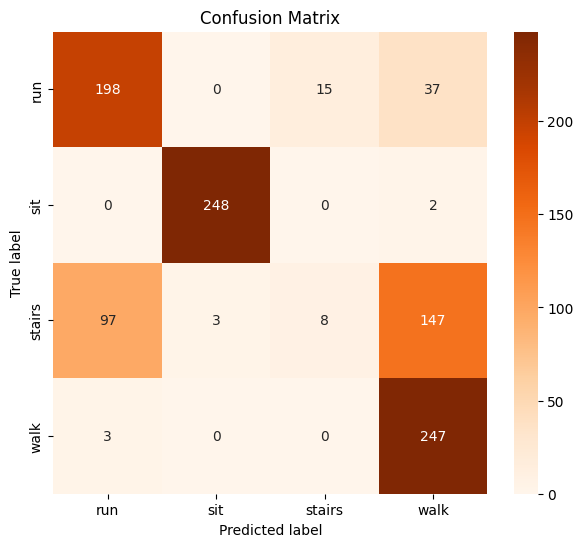

Saved artifact at 'mobilehart_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 6), dtype=tf.float32, name='keras_tensor_340')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132310065264400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132313448249872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310065265744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310065262672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310065266128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310065264208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310065263248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310065264976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132311226915856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310065265360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1323100652

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
if __name__ == "__main__":
    recordings = load_selected_csvs(DATA_DIR)
    if recordings:
        run_experiment(recordings)